In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
          order_id  order_date   ship_date       ship_mode    customer_name  \
0     AG-2011-2040  2011-01-01  2011-01-06  Standard Class  Toby Braunhardt   
1    IN-2011-47883  2011-01-01  2011-01-08  Standard Class      Joseph Holt   
2     HU-2011-1220  2011-01-01  2011-01-05    Second Class    Annie Thurman   
3  IT-2011-3647632  2011-01-01  2011-01-05    Second Class     Eugene Moren   
4    IN-2011-47883  2011-01-01  2011-01-08  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

                  product_name  sales quantity discount   profit  \
0          Tenex Lo

In [3]:
print("Dataset shape:")
print(df.shape)

Dataset shape:
(51290, 23)


In [4]:
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
              sales      quantity      discount        profit  shipping_cost  \
count  51290.000000  51290.000000  51290.000000  51290.000000   51290.000000   
mean     246.498440      3.476545      0.142908     28.641740      26.375915   
std      487.567175      2.278766      0.212280    174.424113      57.296804   
min        0.000000      1.000000      0.000000  -6599.978000       0.000000   
25%       31.000000      2.000000      0.000000      0.000000       2.610000   
50%       85.000000      3.000000      0.000000      9.240000       7.790000   
75%      251.000000      5.000000      0.200000     36.810000      24.450000   
max    22638.000000     14.000000      0.850000   8399.976000     933.570000   

               year  shipping_days  profit_margin  
count  51290.000000   51290.000000   5.129000e+04  
mean    2012.777208       3.969370           -inf  
std        1.098931       1.729437            NaN  
min     2011.000000       0.000000           -inf  

C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
shipping_days     0
profit_margin     0
dtype: int64


In [6]:
print("Duplicate rows:")
print(df.duplicated().sum())

Duplicate rows:
0


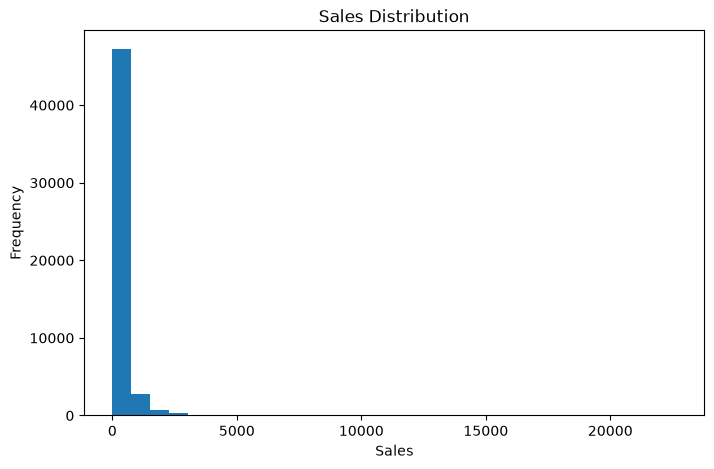

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(df["sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

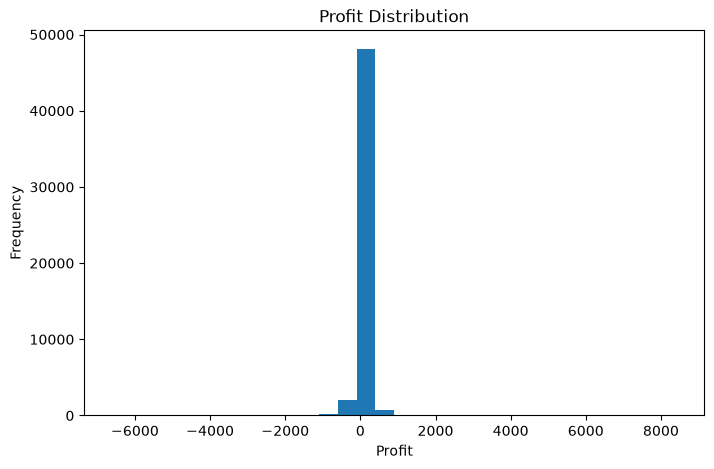

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["profit"], bins=30)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

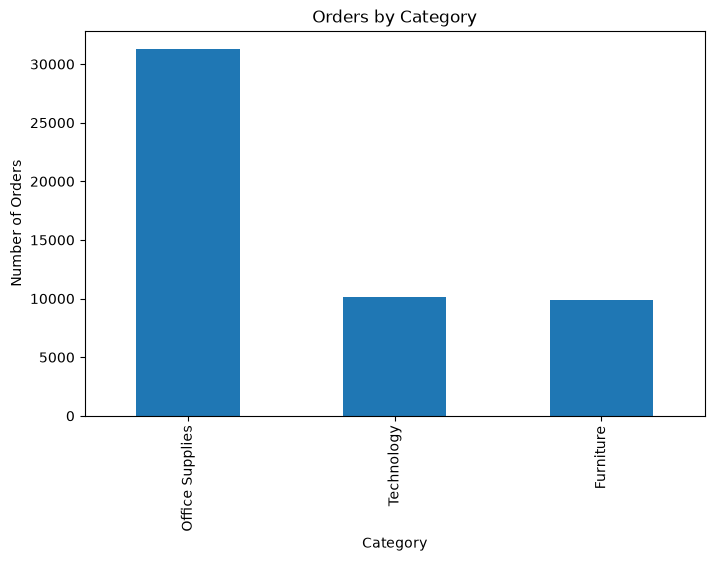

In [9]:
plt.figure(figsize=(8, 5))

df["category"].value_counts().plot(kind="bar")

plt.title("Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.show()

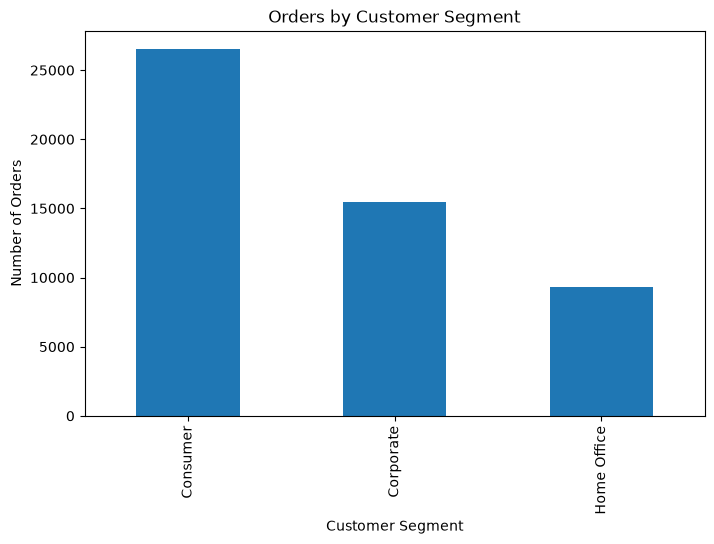

In [10]:
plt.figure(figsize=(8, 5))

df["segment"].value_counts().plot(kind="bar")

plt.title("Orders by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")

plt.show()

In [11]:
print("Average Profit by Category:")
print(df.groupby("category")["profit"].mean().sort_values(ascending=False))

Average Profit by Category:
category
Technology         65.454958
Furniture          29.038300
Office Supplies    16.578961
Name: profit, dtype: float64


In [12]:
print("Average Profit by Category:")
print(df.groupby("category")["profit"].mean().sort_values())

Average Profit by Category:
category
Office Supplies    16.578961
Furniture          29.038300
Technology         65.454958
Name: profit, dtype: float64


In [13]:
print("Top 5 Most Profitable Products:")

top_products = (
    df.groupby("product_name")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_products)

Top 5 Most Profitable Products:
product_name
Canon imageCLASS 2200 Advanced Copier    25199.9280
Cisco Smart Phone, Full Size             17238.5206
Motorola Smart Phone, Full Size          17027.1130
Hoover Stove, Red                        11807.9690
Sauder Classic Bookcase, Traditional     10672.0730
Name: profit, dtype: float64


In [14]:
print("5 Least Profitable Products:")

bottom_products = (
    df.groupby("product_name")["profit"]
    .sum()
    .sort_values()
    .head(5)
)

print(bottom_products)

5 Least Profitable Products:
product_name
Cubify CubeX 3D Printer Double Head Print   -8879.9704
Lexmark MX611dhe Monochrome Laser Printer   -4589.9730
Motorola Smart Phone, Cordless              -4447.0380
Cubify CubeX 3D Printer Triple Head Print   -3839.9904
Bevis Round Table, Adjustable Height        -3649.8940
Name: profit, dtype: float64


In [15]:
print("Top 5 Regions by Number of Orders:")

print(df["region"].value_counts().head(5))

Top 5 Regions by Number of Orders:
region
Central    11117
South       6645
EMEA        5029
North       4785
Africa      4587
Name: count, dtype: int64


In [16]:
print("Business Insights:")

print("1. Sales are unevenly distributed, with most orders having relatively lower sales.")

print("2. Profit varies significantly across orders, and some orders generate negative profit.")

print("3. Technology, Furniture, and Office Supplies have different order volumes.")

print("4. Customer segments have different numbers of orders, with Consumer being a major segment.")

print("5. Different products and regions contribute differently to overall business performance.")

Business Insights:
1. Sales are unevenly distributed, with most orders having relatively lower sales.
2. Profit varies significantly across orders, and some orders generate negative profit.
3. Technology, Furniture, and Office Supplies have different order volumes.
4. Customer segments have different numbers of orders, with Consumer being a major segment.
5. Different products and regions contribute differently to overall business performance.
